# looking at project euler problem difficulty

I was curious about the difficulty of problems in project euler and wanted to plot the number of people who had solved different problems as time went by to see if there were any stand out problems that are notable. below i got chat to cook up a way to access the site and grab the data from each table. 

fetching page 1/20...
fetching page 2/20...
fetching page 3/20...
fetching page 4/20...
fetching page 5/20...
fetching page 6/20...
fetching page 7/20...
fetching page 8/20...
fetching page 9/20...
fetching page 10/20...
fetching page 11/20...
fetching page 12/20...
fetching page 13/20...
fetching page 14/20...
fetching page 15/20...
fetching page 16/20...
fetching page 17/20...
fetching page 18/20...
fetching page 19/20...
fetching page 20/20...


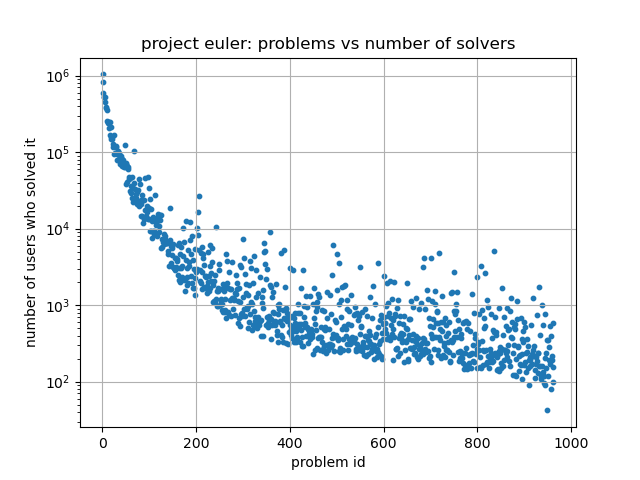

In [2]:
#!/usr/bin/env python3

import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt


BASE_URL = "https://projecteuler.net/archives"
NUM_PAGES = 20  # per your observation


def fetch_page_html(page_index: int) -> str:
    """
    fetch the html for the given archive page.
    page_index starts at 1.
    page 1 is just BASE_URL, later pages look like BASE_URL;page=2 etc.
    """
    if page_index == 1:
        url = BASE_URL
    else:
        url = f"{BASE_URL};page={page_index}"

    resp = requests.get(url, timeout=10)
    resp.raise_for_status()
    return resp.text


def find_problem_table(soup: BeautifulSoup):
    """
    find the table that has header columns including 'id' and 'solved by'.
    this avoids depending on specific css classes that might change.
    """
    for table in soup.find_all("table"):
        header_row = table.find("tr")
        if not header_row:
            continue
        headers = [th.get_text(strip=True).lower() for th in header_row.find_all("th")]
        if "id" in headers and "solved by" in headers:
            return table
    return None


def parse_archive_page(html: str):
    """
    parse a single archive page and return lists of (problem_id, solved_by).
    """
    soup = BeautifulSoup(html, "html.parser")
    table = find_problem_table(soup)
    if table is None:
        raise RuntimeError("could not find the problem table on this page")

    # assume first row is header; rest are data rows
    rows = table.find_all("tr")[1:]

    ids = []
    solved = []

    for row in rows:
        cells = row.find_all(["td", "th"])
        if len(cells) < 3:
            continue

        try:
            problem_id_text = cells[0].get_text(strip=True)
            solved_text = cells[-1].get_text(strip=True)

            # parse ints, stripping commas / spaces
            problem_id = int(problem_id_text.replace(",", "").replace(" ", ""))
            solved_by = int(solved_text.replace(",", "").replace(" ", ""))

            ids.append(problem_id)
            solved.append(solved_by)
        except ValueError:
            # skip rows that don't parse cleanly (e.g. weird footer rows)
            continue

    return ids, solved


def main():
    all_ids = []
    all_solved = []

    for page in range(1, NUM_PAGES + 1):
        print(f"fetching page {page}/{NUM_PAGES}...", flush=True)
        html = fetch_page_html(page)
        ids, solved = parse_archive_page(html)
        all_ids.extend(ids)
        all_solved.extend(solved)

    # sort by problem id in case the site ever returns them out of order
    paired = sorted(zip(all_ids, all_solved), key=lambda p: p[0])
    problem_ids, solved_counts = zip(*paired)

    plt.figure()
    plt.scatter(problem_ids, solved_counts, s=10)
    plt.xlabel("problem id")
    plt.ylabel("number of users who solved it")
    plt.title("project euler: problems vs number of solvers")
    plt.yscale('log')
    plt.grid(True)

    # show on screen; if you want to save instead, use plt.savefig("euler_solved_by.png")
    plt.show()


if __name__ == "__main__":
    main()
